<a href="https://colab.research.google.com/github/hasana1atwit/Movie-Analysis/blob/main/Movie_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSV Import
To access csv data file, first upload to google drive, then run the following code:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


After granting colab access to your files, copy the file path and run the next cell to read the data csv.

In [ ]:
import pandas as pd
file_path = '/content/drive/MyDrive/movies_dataset.csv' # Paste your path here using the Files tab on the left hand side
movies = pd.read_csv(file_path)

# 1. Does a movie's budget affect its success?

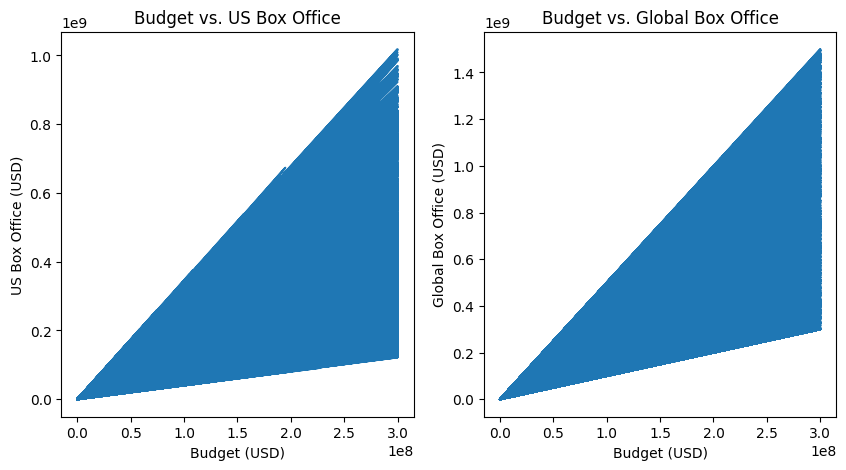

In [ ]:
import matplotlib.pyplot as plt

#scatter plot budget
x = movies['BudgetUSD']
y1 = movies['US_BoxOfficeUSD']
y2 = movies['Global_BoxOfficeUSD']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.plot(x,y1)
ax1.set_xlabel('Budget (USD)')
ax1.set_ylabel('US Box Office (USD)')
ax1.set_title('Budget vs. US Box Office')

ax2.plot(x,y2)
ax2.set_xlabel('Budget (USD)')
ax2.set_ylabel('Global Box Office (USD)')
ax2.set_title('Budget vs. Global Box Office')

plt.show()

In [ ]:
# US Box Office p_value
import statsmodels.api as sm

x = sm.add_constant(x)
statModel1 = sm.OLS(y1, x).fit()
#print(model.summary())
statModel1.pvalues

,0
const,0.051781
BudgetUSD,0.000000


In [ ]:
# Global Box Office_pvalue
import statsmodels.api as sm

x = sm.add_constant(x)
statModel2 = sm.OLS(y2, x).fit()
#print(model.summary())
statModel2.pvalues

,0
const,0.043547
BudgetUSD,0.000000


In [ ]:
# US Box Office R^2
r1 = statModel1.rsquared
r1

np.float64(0.7791456538946241)

In [ ]:
# Global Box Office R^2
r2 = statModel2.rsquared
r2

np.float64(0.8018473295068537)

In [ ]:
# US Box Office Parameters
statModel1.params

,0
const,38679.951094
BudgetUSD,1.522312


In [ ]:
# Global Box office Parameters
statModel2.params

,0
const,68159.129910
BudgetUSD,2.768396


# 2. Does the majority of profit come from the country it was made in or internationally?


In [ ]:
import seaborn as sns

cols_needed = ['Country', 'US_BoxOfficeUSD', 'Global_BoxOfficeUSD', 'BudgetUSD', 'ReleaseYear']
df = pd.read_csv('movies_dataset.csv', usecols=cols_needed)

#filter USA movies
df = df[df['Country'] == 'USA']

#optomize oversized data
for col in ['US_BoxOfficeUSD', 'Global_BoxOfficeUSD', 'BudgetUSD']:
    df[col] = pd.to_numeric(df[col], errors='coerce', downcast='float')

df['ReleaseYear'] = pd.to_numeric(df['ReleaseYear'], errors='coerce', downcast='integer')

df = df.dropna()

In [ ]:
#Create international Revenue value
df['International_BoxOfficeUSD'] = df['Global_BoxOfficeUSD'] - df['US_BoxOfficeUSD']

# Remove invalid data
df = df[
    (df['BudgetUSD'] > 0) &
    (df['US_BoxOfficeUSD'] > 0) &
    (df['International_BoxOfficeUSD'] > 0)
]

In [ ]:
total_domestic = df['US_BoxOfficeUSD'].sum()
total_international = df['International_BoxOfficeUSD'].sum()

print(f"\nAnalysis of {len(df)} USA-made movies\n")
print(f"Total Domestic:      ${total_domestic:,.2f}")
print(f"Total International: ${total_international:,.2f}")

In [ ]:
df['Total_Revenue'] = df['US_BoxOfficeUSD'] + df['International_BoxOfficeUSD']

df = df[df['Total_Revenue'] > 0]

df['Domestic_Share'] = df['US_BoxOfficeUSD'] / df['Total_Revenue']
df['International_Share'] = df['International_BoxOfficeUSD'] / df['Total_Revenue']

yearly_share = df.groupby('ReleaseYear', as_index=False)[
    ['Domestic_Share', 'International_Share']
].mean()

plt.figure(figsize=(10, 6))
plt.bar(yearly_share['ReleaseYear'], yearly_share['Domestic_Share'], label='Domestic')
plt.bar(
    yearly_share['ReleaseYear'],
    yearly_share['International_Share'],
    bottom=yearly_share['Domestic_Share'],
    label='International'
)
plt.legend()
plt.title('Revenue Share Over Time')
plt.show()

In [ ]:
wins = (df['International_BoxOfficeUSD'] > df['US_BoxOfficeUSD']).value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    wins,
    labels=['International > Domestic', 'Domestic > International'],
    autopct='%1.1f%%'
)
plt.title('Which Market Wins Per Movie')
plt.show()

# 3. Do shorter movie titles make more money?

In [ ]:
import matplotlib.pyplot as plt

#create a new column for the lengths of the movie titles
movies['Title_len'] = movies['Title'].str.len()

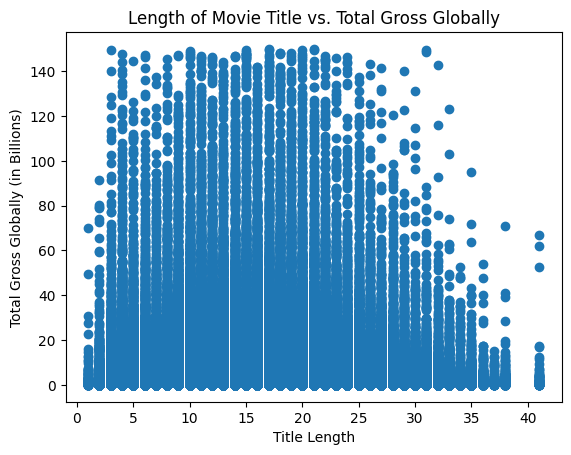

In [ ]:
#scatter plot title length vs. total gross
plt.scatter(movies['Title_len'], movies['Global_BoxOfficeUSD'] / 10000000)
plt.title('Length of Movie Title vs. Total Gross Globally')
plt.xlabel('Title Length')
plt.ylabel('Total Gross Globally (in Billions)')
plt.show()

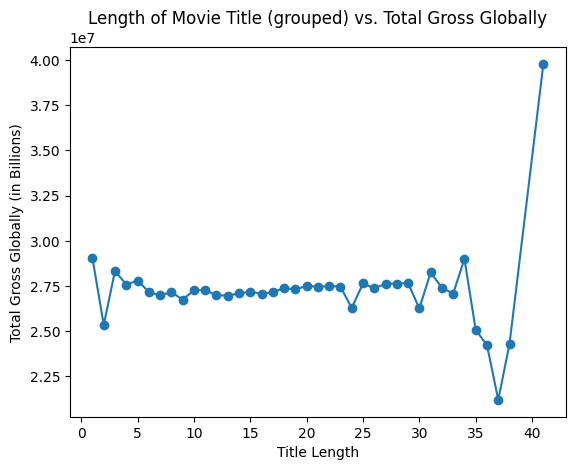

In [ ]:
# the scatter plot was too difficult to assess at a glance
# create groups and plot group means instead

# add new column for mean total gross by title length
movies['Gross_by_title_len'] = movies.groupby('Title_len')['Global_BoxOfficeUSD'].mean()

# plot grouped title lengths and total gross
plt.plot(movies.groupby('Title_len')['Global_BoxOfficeUSD'].mean(), marker='o')
plt.title('Length of Movie Title (grouped) vs. Total Gross Globally')
plt.xlabel('Title Length')
plt.ylabel('Total Gross Globally (in Billions)')
plt.show()

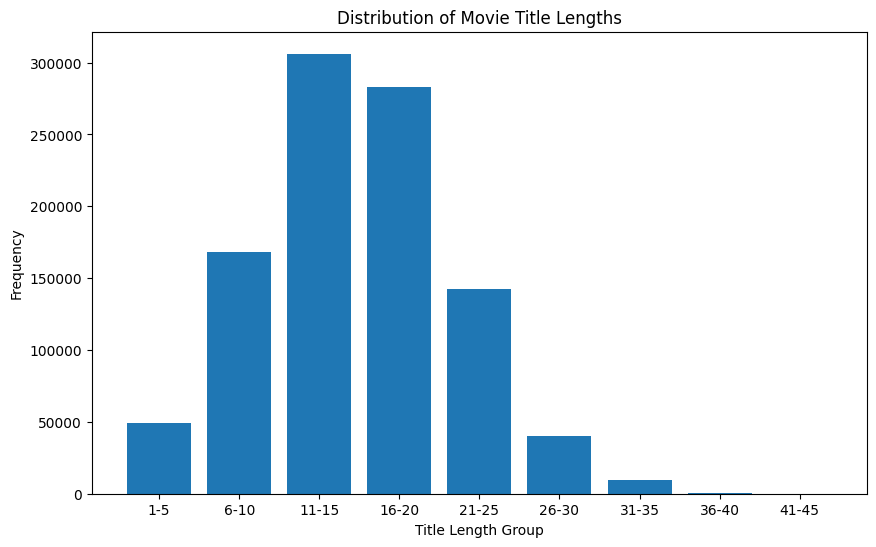

In [ ]:
# even further, create categories of lengths to compare averages
# categorical data can be analyzed using one-way ANOVA

import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols

# create categories
# max(movies['Title_len']) = 41, so categories should stop around then
bins = [1, 6, 11, 16, 21, 26, 31, 36, 41, 45] # values to portion out categories
labels = ['1-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31-35', '36-40', '41-45']

movies['Title_len_5s'] = pd.cut(movies['Title_len'], bins=bins, labels=labels, right=False) # new column of titles grouped by fives

# show distribution
plt.figure(figsize=(10,6))
plt.bar(movies['Title_len_5s'].value_counts().sort_index().index, movies['Title_len_5s'].value_counts().sort_index().values)
plt.xlabel('Title Length Group')
plt.ylabel('Frequency')
plt.title('Distribution of Movie Title Lengths')
plt.show()

In [ ]:
# define the OLS model for ANOVA use
model = ols('Global_BoxOfficeUSD ~ C(Title_len_5s)', data=movies).fit()

# perform the ANOVA and print the table
anova_table = sm.stats.anova_lm(model, typ=1)
print(anova_table)

                       df        sum_sq       mean_sq         F    PR(>F)
C(Title_len_5s)       8.0  4.878118e+16  6.097648e+15  1.260832  0.258998
Residual         999990.0  4.836162e+21  4.836210e+15       NaN       NaN


The p-value of the one-way ANOVA is 0.258998. The null hypothesis is that the length of movie titles does not affect the total box office revenue. Since the resulting p-value is greater than 0.05, we fail to reject the null hypothesis. This means that there is no correlation between the lengths of movie titles and their total gross.